In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('weight-height.csv')

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
df.shape

(10000, 3)

In [5]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [6]:

import seaborn as sns

<Axes: xlabel='Height', ylabel='Count'>

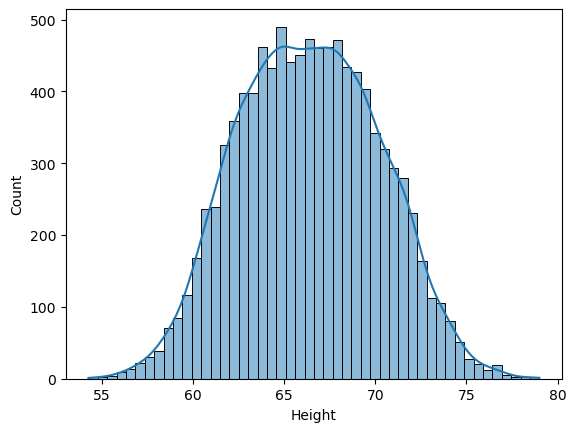

In [7]:
sns.histplot(df['Height'],kde=True)

<Axes: ylabel='Height'>

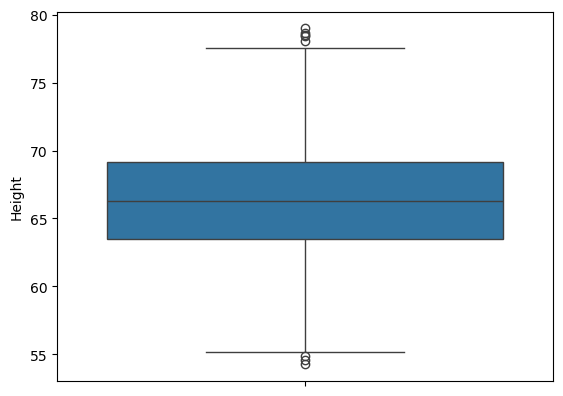

In [8]:
sns.boxplot(df['Height'])

In [9]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

74.7857900583366

In [10]:

lower_limit = df['Height'].quantile(0.01)
lower_limit



58.13441158671655

In [11]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [12]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

C:\Users\Shafayet 777\AppData\Local\Temp\ipykernel_13340\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

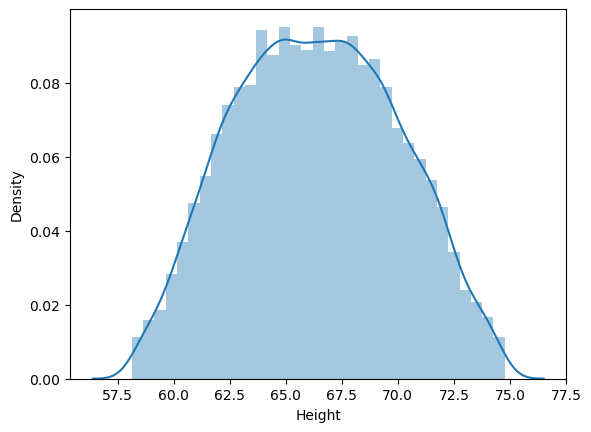

In [13]:
sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

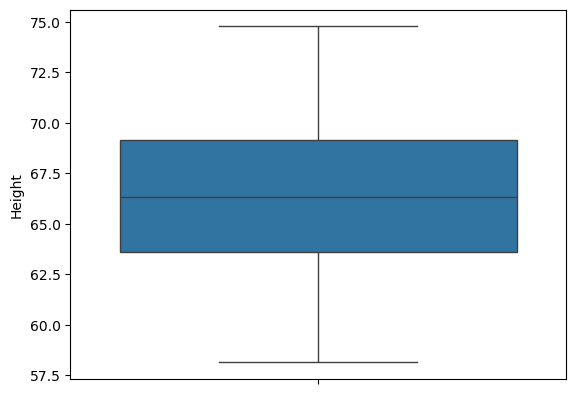

In [14]:

sns.boxplot(new_df['Height'])

In [15]:
# Capping --> Winsorization
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [16]:
df.shape


(10000, 3)

In [17]:

df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

C:\Users\Shafayet 777\AppData\Local\Temp\ipykernel_13340\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

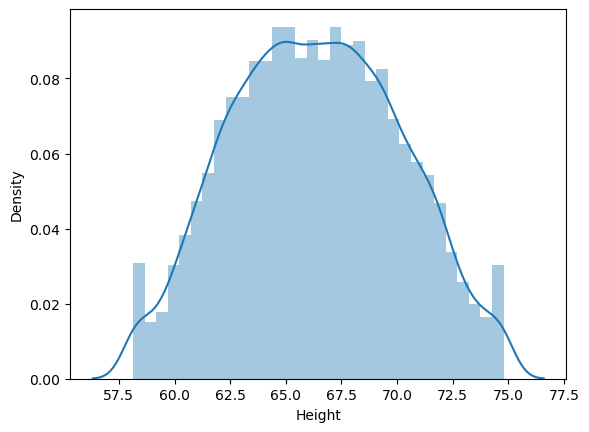

In [18]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

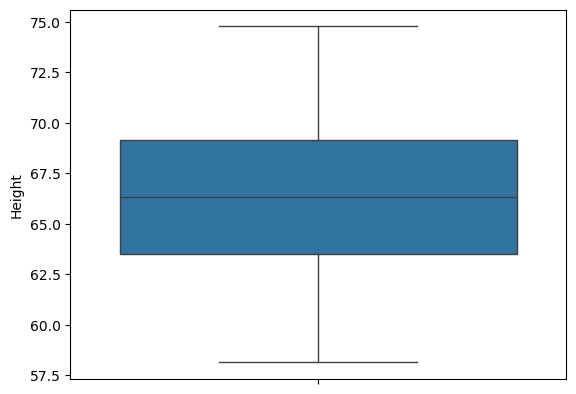

In [19]:
sns.boxplot(df['Height'])

## **winsorization using scipi library**


In [21]:
from scipy.stats.mstats import winsorize
import numpy as np
winsorized_data = winsorize(df['Height'], limits=[0.01, 0.01])

In [22]:
print(winsorized_data)

[73.84701702 68.78190405 74.11010539 ... 63.86799221 69.03424313
 61.94424588]


C:\Users\Shafayet 777\AppData\Local\Temp\ipykernel_13340\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

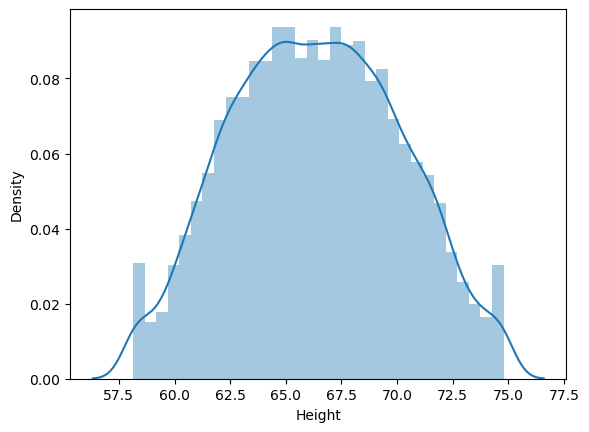

In [23]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

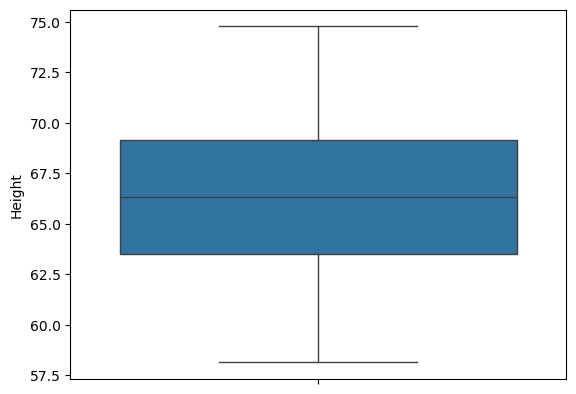

In [24]:
sns.boxplot(df['Height'])


## **feature_engine diyeo kora jay**

In [25]:
!pip install feature-engine

In [28]:
from feature_engine.outliers import Winsorizer
import pandas as pd


# Initialize Winsorizer
winsor = Winsorizer(capping_method='iqr',  # 'gaussian' or 'quantiles' also supported
                    tail='both',           # 'right', 'left', or 'both'
                    fold=1.5,              # IQR multiplier
                    variables=['Height'])
# Fit and transform
df_winsorized = winsor.fit_transform(df)
print(df_winsorized)


      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [29]:
winsor

Winsorizer(capping_method='iqr', fold=1.5, tail='both', variables=['Height'])